In [109]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Simple Linear Regression (Built-in Libraries)

In [110]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [111]:
data = {
    'Length': [1.8, 1.85, 1.9, 2.0, 2.1, 2.2, 2.25, 2.3, 2.4, 2.5, 2.6, 2.7],
    'Age':    [0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 7.0, 8.0, 10.0, 15.0, 20.0, 30.0]
}
df = pd.DataFrame(data)

In [112]:
X = df[['Length']]
y = df['Age']

In [113]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

In [114]:
print(len(x_train))
print(len(x_test))

8
4


In [115]:
model = LinearRegression().fit(x_train, y_train)

In [116]:
print(model.coef_[0])
print(model.intercept_)

22.686015831134565
-42.07994722955145


In [117]:
model.score(x_train, y_train)

0.9222428563408747

In [118]:
model.score(x_test, y_test)

0.7413456358439505

In [119]:
y_pred = model.predict(x_train)

In [120]:
print(x_train.T)
print(y_pred)

         4    9    10   8    3    0     6    2 
Length  2.1  2.5  2.6  2.4  2.0  1.8  2.25  1.9
[ 5.56068602 14.63509235 16.90369393 12.36649077  3.29208443 -1.24511873
  8.96358839  1.02348285]


In [121]:
y_pred_test = model.predict(x_test)

In [122]:
print(x_test.T)
print(y_pred_test)

         7     1    5    11
Length  2.3  1.85  2.2  2.7
[10.09788918 -0.11081794  7.8292876  19.17229551]


In [123]:
MSE = mean_squared_error(y_test, y_pred_test)
print(f"MSE: {MSE}")

MSE: 32.71977706574025


In [124]:
r2 = r2_score(y_test, y_pred_test)
print(f"r2: {r2}")

r2: 0.7413456358439505


In [125]:
r = np.sqrt(r2)
print(f"Correlation r: {r}")

Correlation r: 0.8610143064107301


In [126]:
residuals = y_train - y_pred

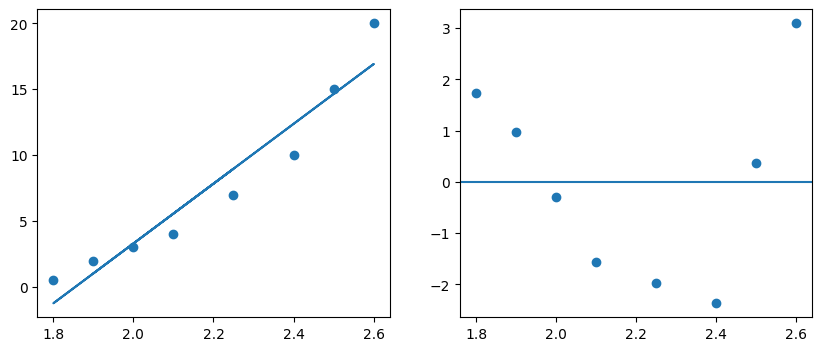

In [127]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(x_train, y_train)
plt.plot(x_train, y_pred)

plt.subplot(1,2,2)
plt.scatter(x_train, residuals)
plt.axhline(y=0)

plt.show()

# Transformed Simple Linear Regression (Theory)

Apply a log transformation on the target with: 

- df['Log_Age'] = np.log(df['Age'])

And then train a linear model on the transformed target.

To look at the prediction on the original data

- df['Age_Predicted'] = np.exp(df['Log_Predicted'])

# Multiple Linear Regression (Built-in Libraries)

In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [129]:
np.random.seed(42) # For reproducible results
n_samples = 500

# Feature 1: House Size (sq ft)
size = np.random.randint(500, 3500, n_samples)

# Feature 2: Number of Bedrooms
bedrooms = np.random.randint(1, 6, n_samples)

# Target: Price ($) + Random Noise (Standard deviation = 15k)
noise = np.random.normal(0, 15000, n_samples)
price = 50000 + (150 * size) + (25000 * bedrooms) + noise

# Store in DataFrame
df = pd.DataFrame({'Size': size, 'Bedrooms': bedrooms, 'Price': price})

print("--- Data Snapshot ---")
print(df.head())
print("-" * 30)

--- Data Snapshot ---
   Size  Bedrooms          Price
0  1360         5  390442.709362
1  1794         4  428669.500485
2  1630         2  337863.514376
3  1595         4  396130.652573
4  2138         2  430500.996069
------------------------------


In [130]:
X = df[['Size', 'Bedrooms']]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
print(len(X_train))
print(len(y_train))
print(len(X_test))
print(len(y_test))

375
375
125
125


In [131]:
model = LinearRegression().fit(X_train, y_train)

In [132]:
model.score(X_train, y_train)

0.9863940064282413

In [133]:
y_test_pred = model.predict(X_test)

In [134]:
print(y_test_pred)

[550634.80468882 237321.17850151 271809.60940016 299163.36615064
 230054.08304891 196469.2791607  589547.02870431 640979.32253601
 178641.68538893 426329.82818627 250311.24502026 682696.76951823
 378080.12506285 453231.77143153 431450.38124546 460422.70814605
 606960.8883399  424635.09929808 381957.76273907 652575.86917006
 611366.49825942 406411.95458744 259460.04025741 693239.08464009
 405697.01144777 542502.16159481 520194.51213985 549373.70610854
 687666.71807567 392556.34042728 469252.11118241 365071.87534678
 391238.97928065 389977.88070037 166649.58781601 328850.6361909
 498977.46059171 371905.34049147 556715.2473248  313187.76800985
 511533.89680255 590828.02345631 578552.90007723 521098.1391503
 251383.65972976 453249.95462884 485818.6063739  322224.03811431
 309856.28577424 393837.33517928 422452.19051004 675015.93992944
 634653.9334629  203585.77011156 381957.76273907 523564.0737445
 579287.73938862 568763.60746407 654740.59476078 377477.70705588
 358764.66947098 294193.4175

In [135]:
intercept = model.intercept_
intercept

51192.19754713331

In [136]:
thetas = model.coef_
thetas

array([  150.60450174, 24642.87571915])

In [137]:
r2_score(y_test, y_test_pred)

0.9849062200195546

In [138]:
MSE = mean_squared_error(y_test, y_test_pred)
MSE

299449607.1835714

In [139]:
RMSE = np.sqrt(MSE)
print(f"RMSE (same unit as target, i.e. dollars): {RMSE}")

RMSE (same unit as target, i.e. dollars): 17304.612309542546


In [140]:
print("R2 is 98%, which suggests that the model is able to explain 98% of the data accurately. The rest 2% is noise, which our selected features are unable to explain, such as the color of the house or the owner of the house put too much price on the house without proper market research.")

R2 is 98%, which suggests that the model is able to explain 98% of the data accurately. The rest 2% is noise, which our selected features are unable to explain, such as the color of the house or the owner of the house put too much price on the house without proper market research.


In [141]:
print("RMSE is 17k dollars, which means, our predictions for house prices are off by an average of 17K dollars.")

RMSE is 17k dollars, which means, our predictions for house prices are off by an average of 17K dollars.


# Multiple Linear Regression (Manual)

In [142]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

df.head()

,Size,Bedrooms,Price
0,1360,5,390442.709362
1,1794,4,428669.500485
2,1630,2,337863.514376
3,1595,4,396130.652573
4,2138,2,430500.996069


In [143]:
X = df[['Size', 'Bedrooms']].to_numpy()
y = df['Price'].to_numpy()
print(X.shape)
print(y.shape)

(500, 2)
(500,)


In [144]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(len(X_train))
print(len(y_train))
print(len(X_test))
print(len(y_test))

350
350
150
150


In [145]:
ones = np.ones((len(X_train), 1))
X_train = np.hstack((ones, X_train))
X_train.shape

(350, 3)

In [146]:
# Apply the normal equation for optimal parameters

XT = X_train.T
XTX = XT @ X_train
XTX_inv = np.linalg.inv(XTX)
thetas = XTX_inv @ XT @ y_train

intercept = thetas[0]
size_slope = thetas[1]
room_slope = thetas[2]

print(f"Intercept: {intercept:.4f}\nSize Slope: {size_slope:.4f}\nRoom Slope: {room_slope:.4f}")

Intercept: 54709.58748621404
Size Slope: 149.72680057820966
Room Slope: 24049.00828128851


In [147]:
ones = np.ones((len(X_test), 1))
X_test = np.hstack((ones, X_test))

In [148]:
y_pred = X_test @ thetas

In [149]:
residuals = y_test - y_pred
mse = np.mean(residuals**2)
rmse = np.sqrt(mse)

print(f"MSE: {mse:.4f}\nRMSE (same unit as target i.e. dollars): {rmse:.4f}")

MSE: 260499927.0274
RMSE (same unit as target i.e. dollars): 16140.010130956645


In [150]:
r2 = np.var(y_pred) / np.var(y_test)
print(f"R-Squared: {r2:.4f}")

R-Squared: 0.9757


In [151]:
print("RMSE is 16k dollars, which implies that our model are off by an average of 16k dollars when predicting price.")
print("\nR-Squared is 97%, which means our model is able to explain 97% of the test data with the selected features (size, bedrooms). The remaining 3% is noise for which our selected features are unable to explain.")

RMSE is 16k dollars, which implies that our model are off by an average of 16k dollars when predicting price.

R-Squared is 97%, which means our model is able to explain 97% of the test data with the selected features (size, bedrooms). The remaining 3% is noise for which our selected features are unable to explain.


# Constant Model

In [152]:
X = df[['Size', 'Bedrooms']]
y = df['Price'].to_numpy()

In [153]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(len(X_train))
print(len(y_train))
print(len(X_test))
print(len(y_test))

350
350
150
150


In [154]:
theta_0 = np.mean(y_train)
print(f"Optimal Constant: {theta_0:.4f}")

# We create an array of the same size as X, filled with theta_0 for visualization
theta_0_list = np.full(shape=X.shape, fill_value=theta_0)

Optimal Constant: 430526.4201


In [155]:
residuals = y_test - theta_0
mse = np.mean(residuals**2)
rmse = np.sqrt(mse)

print(f"MSE: {mse:.4f}\nRMSE (same unit as target i.e. dollars): {rmse:.4f}")

MSE: 17881592572.2314
RMSE (same unit as target i.e. dollars): 133722.0721


In [156]:
# Note: The variance of a constant list (e.g., [5, 5, 5]) is always 0.
r2 = np.var(theta_0) / np.var(y_test)
print(f"R-Squared: {r2}")

R-Squared: 0.0


In [157]:
print(f"This optimal parameter {theta_0} is the mean of our training set. It represents our best guess if we knew nothing about house sizes.")

This optimal parameter 430526.42008215183 is the mean of our training set. It represents our best guess if we knew nothing about house sizes.


In [158]:
print("The model explains 0% of the variance. Because the predictions are a flat line, they have zero variance = 0$). Since the numerator is 0, the ratio is 0.")
print(f"\nComparing this {rmse} huge error to the much smaller error of our MLR model (from the previous step) proves that our features (Size/Bedrooms) are actually useful.")

The model explains 0% of the variance. Because the predictions are a flat line, they have zero variance = 0$). Since the numerator is 0, the ratio is 0.

Comparing this 133722.07212061665 huge error to the much smaller error of our MLR model (from the previous step) proves that our features (Size/Bedrooms) are actually useful.


# MLR with One-Hot Encoding

In [175]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [176]:
data = {
    'Experience_Years': [1, 2, 3, 5, 8, 10, 1, 3, 5, 7, 2, 4, 6, 9],
    'Education': [
        'High School', 'High School', 'High School', 'High School', 'High School', 'High School',
        'Bachelors', 'Bachelors', 'Bachelors', 'Bachelors',
        'Masters', 'Masters', 'Masters', 'Masters'
    ],
    # The "Hidden" Logic used to generate this:
    # Base (High School) = $30,000 + ($2,000 per year of exp)
    # Bachelors Bonus    = +$10,000
    # Masters Bonus      = +$25,000
    'Salary': [
        32000, 34000, 36000, 40000, 46000, 50000,   # High School
        42000, 46000, 50000, 54000,                 # Bachelors (Base + 10k)
        59000, 63000, 67000, 73000                  # Masters (Base + 25k)
    ]
}

df = pd.DataFrame(data)
print(df.head())
print("-" * 30)

   Experience_Years    Education  Salary
0                 1  High School   32000
1                 2  High School   34000
2                 3  High School   36000
3                 5  High School   40000
4                 8  High School   46000
------------------------------


In [177]:
# Bachelor's will be dropped because alphabetically it comes first, 
# and also that one-hot encoding sorts the columns horizontally. 
df_encoded = pd.get_dummies(df, columns=['Education'], drop_first=True, dtype=int)
df_encoded.head()

,Experience_Years,Salary,Education_High School,Education_Masters
0,1,32000,1,0
1,2,34000,1,0
2,3,36000,1,0
3,5,40000,1,0
4,8,46000,1,0


In [178]:
X = df_encoded.drop(columns=['Salary'])
X.head()

,Experience_Years,Education_High School,Education_Masters
0,1,1,0
1,2,1,0
2,3,1,0
3,5,1,0
4,8,1,0


In [179]:
y = df_encoded['Salary']
y.head()

0    32000
1    34000
2    36000
3    40000
4    46000
Name: Salary, dtype: int64

In [180]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(len(X_train))
print(len(y_train))
print(len(X_test))
print(len(y_test))

10
10
4
4


In [181]:
model = LinearRegression().fit(X_train, y_train)
model.score(X_train, y_train)

1.0

In [182]:
intercept = model.intercept_
coefs = model.coef_
feature_names = X.columns

print("--- Model Results ---")
print(f"Intercept (Baseline): ${intercept:,.2f}")

for name, val in zip(feature_names, coefs):
    print(f"Coefficient for {name}: ${val:,.2f}")

--- Model Results ---
Intercept (Baseline): $40,000.00
Coefficient for Experience_Years: $2,000.00
Coefficient for Education_High School: $-10,000.00
Coefficient for Education_Masters: $15,000.00


In [183]:
y_test_pred = model.predict(X_test)
y_test_pred

array([54000., 63000., 32000., 67000.])

In [184]:
residuals = y_test - y_test_pred
mse = np.mean(residuals**2)
rmse = np.sqrt(mse)

print(f"MSE: {mse:.4f}\nRMSE (same unit as target i.e. dollars): {rmse:.4f}")

MSE: 0.0000
RMSE (same unit as target i.e. dollars): 0.0000


In [185]:
r2 = r2_score(y_test, y_test_pred)
print(f"R-Squared: {r2}")

R-Squared: 1.0


In [188]:
print("RMSE = 0.00 means predictions are exact, all the observed original datapoints lie exactly on the predicted linear regression line. There is no residual at all.")

RMSE = 0.00 means predictions are exact, all the observed original datapoints lie exactly on the predicted linear regression line. There is no residual at all.


In [186]:
print("R2 implies that 100% of the salary differences are explained by Experience and Education")

R2 implies that 100% of the salary differences are explained by Experience and Education
